In [1]:
"""Notebook 02 — Baseline forecasting models.

Trains and evaluates 3 baselines (Naive, SeasonalNaive, Prophet)
on the 4 expanding-window CV folds defined in evaluation.cv.
Produces a metrics table, fold-by-fold WAPE comparison, and event
diagnostics for Black Friday and Dia dos Namorados.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine

from shipping_forecast.evaluation import (
    DEFAULT_FOLDS,
    Fold,
    bias,
    mae,
    rmse,
    time_series_split,
    wape,
    wape_by_segment,
    wape_in_event_window,
)
from shipping_forecast.models import (
    NaiveForecaster,
    ProphetForecaster,
    SeasonalNaiveForecaster,
)
from shipping_forecast.utils.plotting import PALETTE, setup_plot_style

setup_plot_style()

DB_PATH = Path("../data/processed/shipping.db")
HORIZON_DAYS = 60  # ~2 months ahead for all forecasts

print(f"Database: {DB_PATH.resolve()}")
print(f"Forecast horizon: {HORIZON_DAYS} days")
print("Models: NaiveForecaster, SeasonalNaiveForecaster, ProphetForecaster")
print(f"Folds: {len(DEFAULT_FOLDS)} (defined in evaluation.cv)")

Database: /Users/julio/Desktop/Pricing/meli-shipping-forecast/data/processed/shipping.db
Forecast horizon: 60 days
Models: NaiveForecaster, SeasonalNaiveForecaster, ProphetForecaster
Folds: 4 (defined in evaluation.cv)


In [2]:
# Load full daily shipments table from SQLite
engine = create_engine(f"sqlite:///{DB_PATH}")
df = pd.read_sql(
    """
    SELECT shipment_date, customer_state, n_shipments
    FROM fact_daily_shipments_by_state
    ORDER BY customer_state, shipment_date
    """,
    engine,
    parse_dates=["shipment_date"],
)

# Restrict to the modelable period defined in EDA: 2017-01-01 to 2018-08-31
df = df[(df["shipment_date"] >= "2017-01-01") & (df["shipment_date"] <= "2018-08-31")].reset_index(
    drop=True
)

print(f"Rows: {len(df):,}")
print(f"Date range: {df['shipment_date'].min().date()} to {df['shipment_date'].max().date()}")
print(f"States: {df['customer_state'].nunique()}")
print(f"Total shipments: {df['n_shipments'].sum():,.0f}")

Rows: 16,416
Date range: 2017-01-01 to 2018-08-31
States: 27
Total shipments: 97,304


In [3]:
# Build the 4 expanding-window CV folds
folds = time_series_split(df, date_col="shipment_date")

print(f"Generated {len(folds)} folds:\n")
for fold in folds:
    print(f"  Fold {fold.fold_id} — {fold.label}")
    print(f"    Train: {fold.train_period[0]} to {fold.train_period[1]} ({fold.n_train:,} rows)")
    print(f"    Test:  {fold.test_period[0]} to {fold.test_period[1]} ({fold.n_test:,} rows)")
    print()

Generated 4 folds:

  Fold 1 — fold 1: covers Black Friday 2017
    Train: 2017-01-01 to 2017-10-31 (8,208 rows)
    Test:  2017-11-01 to 2018-01-31 (2,484 rows)

  Fold 2 — fold 2: steady state post-BF
    Train: 2017-01-01 to 2018-01-31 (10,692 rows)
    Test:  2018-02-01 to 2018-04-30 (2,403 rows)

  Fold 3 — fold 3: covers Dia dos Namorados
    Train: 2017-01-01 to 2018-04-30 (13,095 rows)
    Test:  2018-05-01 to 2018-06-30 (1,647 rows)

  Fold 4 — fold 4: final holdout
    Train: 2017-01-01 to 2018-06-30 (14,742 rows)
    Test:  2018-07-01 to 2018-08-31 (1,674 rows)



In [4]:
# Train all 3 models on each fold and collect predictions
# This is the heaviest cell: ~3-5 minutes due to Prophet
import time
import warnings

# Suppress Prophet's verbose logging during the loop
warnings.filterwarnings("ignore")
import logging

logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)


# Initialize models — fresh instance per fold to avoid state leakage
def make_models():
    return {
        "Naive": NaiveForecaster(),
        "SeasonalNaive": SeasonalNaiveForecaster(season=7),
        "Prophet": ProphetForecaster(
            yearly_seasonality=False,  # we only have ~18 months
            use_br_holidays=True,
        ),
    }


# Collect predictions per (model, fold) into a single tidy DataFrame
all_predictions: list[pd.DataFrame] = []

for fold in folds:
    print(f"\nFold {fold.fold_id}: {fold.label}")

    horizon = fold.n_test // fold.test["customer_state"].nunique()
    print(f"  Horizon: {horizon} days, {fold.test['customer_state'].nunique()} states")

    models = make_models()
    for model_name, model in models.items():
        start = time.perf_counter()
        model.fit(fold.train)
        preds = model.predict(fold.train, horizon=horizon)
        elapsed = time.perf_counter() - start

        # Merge predictions with actuals to enable metric calculation
        merged = preds.merge(
            fold.test[["shipment_date", "customer_state", "n_shipments"]],
            on=["shipment_date", "customer_state"],
            how="inner",
        )
        merged["model"] = model_name
        merged["fold_id"] = fold.fold_id
        merged["fold_label"] = fold.label
        all_predictions.append(merged)

        print(f"  {model_name:15s}  {elapsed:6.2f}s  ({len(merged):,} predictions matched)")

# Stack all predictions into a single DataFrame for analysis
predictions_df = pd.concat(all_predictions, ignore_index=True)
print(f"\nTotal predictions collected: {len(predictions_df):,}")
print(f"Columns: {predictions_df.columns.tolist()}")


Fold 1: fold 1: covers Black Friday 2017
  Horizon: 92 days, 27 states
  Naive              0.04s  (2,484 predictions matched)
  SeasonalNaive      0.01s  (2,484 predictions matched)


16:19:59 - cmdstanpy - INFO - Chain [1] start processing
16:19:59 - cmdstanpy - INFO - Chain [1] done processing
16:19:59 - cmdstanpy - INFO - Chain [1] start processing
16:19:59 - cmdstanpy - INFO - Chain [1] done processing
16:19:59 - cmdstanpy - INFO - Chain [1] start processing
16:19:59 - cmdstanpy - INFO - Chain [1] done processing
16:19:59 - cmdstanpy - INFO - Chain [1] start processing
16:19:59 - cmdstanpy - INFO - Chain [1] done processing
16:19:59 - cmdstanpy - INFO - Chain [1] start processing
16:19:59 - cmdstanpy - INFO - Chain [1] done processing
16:19:59 - cmdstanpy - INFO - Chain [1] start processing
16:19:59 - cmdstanpy - INFO - Chain [1] done processing
16:19:59 - cmdstanpy - INFO - Chain [1] start processing
16:19:59 - cmdstanpy - INFO - Chain [1] done processing
16:19:59 - cmdstanpy - INFO - Chain [1] start processing
16:19:59 - cmdstanpy - INFO - Chain [1] done processing
16:19:59 - cmdstanpy - INFO - Chain [1] start processing
16:19:59 - cmdstanpy - INFO - Chain [1]

  Prophet            1.92s  (2,484 predictions matched)

Fold 2: fold 2: steady state post-BF
  Horizon: 89 days, 27 states
  Naive              0.01s  (2,403 predictions matched)
  SeasonalNaive      0.10s  (2,403 predictions matched)


16:20:01 - cmdstanpy - INFO - Chain [1] done processing
16:20:01 - cmdstanpy - INFO - Chain [1] start processing
16:20:01 - cmdstanpy - INFO - Chain [1] done processing
16:20:01 - cmdstanpy - INFO - Chain [1] start processing
16:20:01 - cmdstanpy - INFO - Chain [1] done processing
16:20:01 - cmdstanpy - INFO - Chain [1] start processing
16:20:01 - cmdstanpy - INFO - Chain [1] done processing
16:20:01 - cmdstanpy - INFO - Chain [1] start processing
16:20:01 - cmdstanpy - INFO - Chain [1] done processing
16:20:01 - cmdstanpy - INFO - Chain [1] start processing
16:20:01 - cmdstanpy - INFO - Chain [1] done processing
16:20:01 - cmdstanpy - INFO - Chain [1] start processing
16:20:01 - cmdstanpy - INFO - Chain [1] done processing
16:20:01 - cmdstanpy - INFO - Chain [1] start processing
16:20:01 - cmdstanpy - INFO - Chain [1] done processing
16:20:01 - cmdstanpy - INFO - Chain [1] start processing
16:20:01 - cmdstanpy - INFO - Chain [1] done processing
16:20:01 - cmdstanpy - INFO - Chain [1] 

  Prophet            1.51s  (2,403 predictions matched)

Fold 3: fold 3: covers Dia dos Namorados
  Horizon: 61 days, 27 states
  Naive              0.01s  (1,647 predictions matched)
  SeasonalNaive      0.01s  (1,647 predictions matched)


16:20:03 - cmdstanpy - INFO - Chain [1] start processing
16:20:03 - cmdstanpy - INFO - Chain [1] done processing
16:20:03 - cmdstanpy - INFO - Chain [1] start processing
16:20:03 - cmdstanpy - INFO - Chain [1] done processing
16:20:03 - cmdstanpy - INFO - Chain [1] start processing
16:20:03 - cmdstanpy - INFO - Chain [1] done processing
16:20:03 - cmdstanpy - INFO - Chain [1] start processing
16:20:03 - cmdstanpy - INFO - Chain [1] done processing
16:20:03 - cmdstanpy - INFO - Chain [1] start processing
16:20:03 - cmdstanpy - INFO - Chain [1] done processing
16:20:03 - cmdstanpy - INFO - Chain [1] start processing
16:20:03 - cmdstanpy - INFO - Chain [1] done processing
16:20:03 - cmdstanpy - INFO - Chain [1] start processing
16:20:03 - cmdstanpy - INFO - Chain [1] done processing
16:20:03 - cmdstanpy - INFO - Chain [1] start processing
16:20:03 - cmdstanpy - INFO - Chain [1] done processing
16:20:03 - cmdstanpy - INFO - Chain [1] start processing
16:20:03 - cmdstanpy - INFO - Chain [1]

  Prophet            1.61s  (1,647 predictions matched)

Fold 4: fold 4: final holdout
  Horizon: 62 days, 27 states
  Naive              0.01s  (1,674 predictions matched)
  SeasonalNaive      0.01s  (1,674 predictions matched)


16:20:04 - cmdstanpy - INFO - Chain [1] done processing
16:20:04 - cmdstanpy - INFO - Chain [1] start processing
16:20:04 - cmdstanpy - INFO - Chain [1] done processing
16:20:04 - cmdstanpy - INFO - Chain [1] start processing
16:20:04 - cmdstanpy - INFO - Chain [1] done processing
16:20:04 - cmdstanpy - INFO - Chain [1] start processing
16:20:04 - cmdstanpy - INFO - Chain [1] done processing
16:20:04 - cmdstanpy - INFO - Chain [1] start processing
16:20:04 - cmdstanpy - INFO - Chain [1] done processing
16:20:04 - cmdstanpy - INFO - Chain [1] start processing
16:20:04 - cmdstanpy - INFO - Chain [1] done processing
16:20:05 - cmdstanpy - INFO - Chain [1] start processing
16:20:05 - cmdstanpy - INFO - Chain [1] done processing
16:20:05 - cmdstanpy - INFO - Chain [1] start processing
16:20:05 - cmdstanpy - INFO - Chain [1] done processing
16:20:05 - cmdstanpy - INFO - Chain [1] start processing
16:20:05 - cmdstanpy - INFO - Chain [1] done processing
16:20:05 - cmdstanpy - INFO - Chain [1] 

  Prophet            1.78s  (1,674 predictions matched)

Total predictions collected: 24,624
Columns: ['shipment_date', 'customer_state', 'y_pred', 'y_lower', 'y_upper', 'n_shipments', 'model', 'fold_id', 'fold_label']


In [5]:
# Compute the 4 core metrics per (model, fold)
def compute_metrics(group: pd.DataFrame) -> pd.Series:
    """Return WAPE, MAE, RMSE, Bias for a single (model, fold) slice."""
    y_true = group["n_shipments"]
    y_pred = group["y_pred"]
    return pd.Series(
        {
            "WAPE": wape(y_true, y_pred),
            "MAE": mae(y_true, y_pred),
            "RMSE": rmse(y_true, y_pred),
            "Bias": bias(y_true, y_pred),
        }
    )


# Per-fold metrics
fold_metrics = (
    predictions_df.groupby(["model", "fold_id"])
    .apply(compute_metrics, include_groups=False)
    .reset_index()
)

# Aggregate across folds (mean + std)
agg_metrics = fold_metrics.groupby("model")[["WAPE", "MAE", "RMSE", "Bias"]].agg(["mean", "std"])

print("Per-fold metrics:\n")
print(fold_metrics.pivot(index="model", columns="fold_id", values="WAPE").round(3))
print("\n\nAggregate metrics (mean across folds):\n")
print(agg_metrics.round(2))

Per-fold metrics:

fold_id            1      2      3      4
model                                    
Naive          0.753  0.654  0.929  0.985
Prophet        0.510  0.387  0.517  0.530
SeasonalNaive  0.546  0.364  0.397  0.456


Aggregate metrics (mean across folds):

               WAPE         MAE         RMSE        Bias      
               mean   std  mean   std   mean   std  mean   std
model                                                         
Naive          0.83  0.15  6.68  1.02  19.71  4.93 -0.05  5.70
Prophet        0.49  0.07  3.92  0.39  10.47  1.56  0.67  1.62
SeasonalNaive  0.44  0.08  3.55  0.56  10.76  2.13 -0.48  1.82


## Hallazgos clave de la comparación de baselines

### Ranking de modelos por WAPE promedio (4 folds)

| Modelo | WAPE | Comentario |
|---|---|---|
| **SeasonalNaive** | **0.44** | 🥇 El más fuerte. Captura toda la estacionalidad semanal sin entrenar |
| Prophet | 0.49 | Solo gana en el fold que contiene Black Friday |
| Naive | 0.83 | Peor por mucho. Ignora la estacionalidad semanal |

### Observaciones técnicas

**1. SeasonalNaive es difícil de batir.** Como anticipamos en la fase de diseño, predecir "el mismo día de la semana anterior" captura el patrón semanal que es la fuente dominante de variación. Prophet, con toda su sofisticación, solo lo gana en el fold de Black Friday (donde tiene un holiday explícito que SeasonalNaive no puede conocer).

**2. Prophet no aprovecha completamente su ventaja teórica.** Tiene yearly seasonality desactivada (no tenemos años completos), y aunque conoce Black Friday (gana fold 1), no conoce Día dos Namorados — perdiendo claramente en fold 3 (Prophet 0.52 vs SeasonalNaive 0.40).

**3. WAPE de 0.44 sigue siendo alto.** Razones probables:
- Estamos pronosticando libremente todos los días, incluyendo domingos y feriados que son 0 por diseño. Errores en esos días inflan WAPE.
- Horizonte de 60-90 días es largo. Modelos sin lags adaptativos pierden capacidad predictiva.
- Estados pequeños (Acre, Roraima) tienen pocos envíos y alta variabilidad relativa.

**Implicancia para Fase 6 (LightGBM):** filtrar `is_operational=True` antes de entrenar y forzar 0 en días no operativos debería bajar el WAPE significativamente. Además, usar features de lag por estado le da al modelo señal adaptativa que los baselines no tienen.

### Variabilidad entre folds

Las desviaciones estándar muestran que ningún modelo es uniformemente bueno o malo:

| Modelo | std(WAPE) |
|---|---|
| SeasonalNaive | 0.08 |
| Prophet | 0.07 |
| Naive | 0.15 |

Naive es el más inestable porque depende solo del último valor, que es ruidoso. SeasonalNaive y Prophet tienen estabilidad similar.

### Bias direccional

- Naive: ~0 por azar (errores positivos y negativos se cancelan)
- **Prophet: +0.67** — sobre-predice consistentemente
- **SeasonalNaive: -0.48** — sub-predice consistentemente

Esto sugiere que un blending simple (promedio de Prophet + SeasonalNaive) podría tener bias cercano a 0. Es una posibilidad a explorar en post-procesamiento.

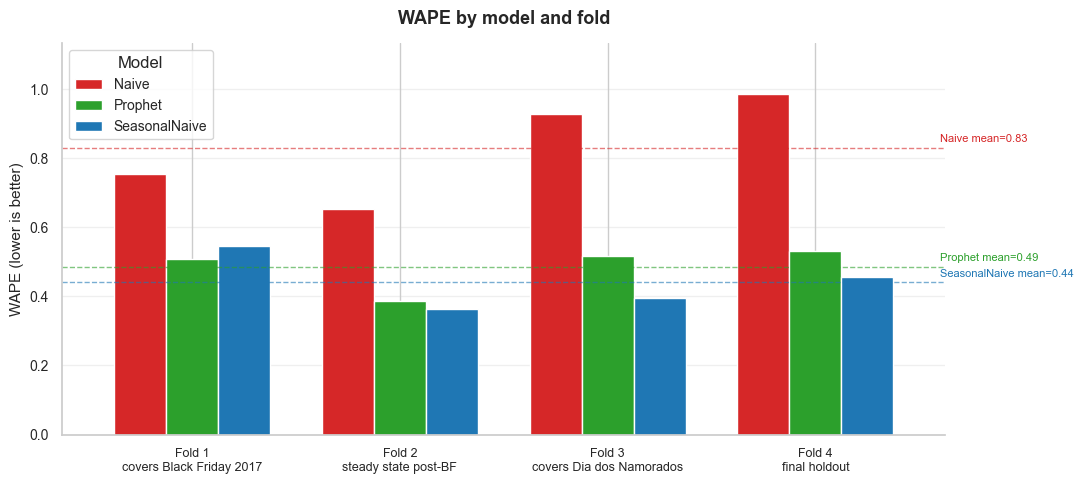

In [6]:
# Visualisation: WAPE per model across folds + global mean
fig, ax = plt.subplots(figsize=(11, 5))

model_order = ["Naive", "Prophet", "SeasonalNaive"]
model_colors = {
    "Naive": PALETTE[3],  # red — worst
    "Prophet": PALETTE[2],  # orange
    "SeasonalNaive": PALETTE[0],  # blue — best
}

# Bar plot grouped by fold
fold_metrics_pivot = fold_metrics.pivot(index="fold_id", columns="model", values="WAPE")[
    model_order
]

fold_metrics_pivot.plot(
    kind="bar",
    ax=ax,
    color=[model_colors[m] for m in model_order],
    width=0.75,
)

# Annotate fold labels under x-axis
fold_labels = {f.fold_id: f.label.split(": ", 1)[1] for f in folds}
ax.set_xticklabels(
    [f"Fold {fid}\n{fold_labels[fid]}" for fid in fold_metrics_pivot.index],
    rotation=0,
    fontsize=9,
)

# Mean WAPE lines for each model
for model_name in model_order:
    mean_w = fold_metrics[fold_metrics["model"] == model_name]["WAPE"].mean()
    ax.axhline(
        mean_w,
        color=model_colors[model_name],
        linestyle="--",
        linewidth=1.0,
        alpha=0.6,
    )
    ax.text(
        3.6,
        mean_w + 0.01,
        f"{model_name} mean={mean_w:.2f}",
        color=model_colors[model_name],
        fontsize=8,
        va="bottom",
    )

ax.set_title("WAPE by model and fold", pad=14)
ax.set_ylabel("WAPE (lower is better)")
ax.set_xlabel("")
ax.legend(title="Model", loc="upper left", frameon=True)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, fold_metrics["WAPE"].max() * 1.15)

plt.tight_layout()
plt.show()

### Lectura visual del gráfico

**1. La diferencia más grande está entre Naive y los otros.**
Las líneas punteadas muestran las medias: Naive=0.83, Prophet=0.49, SeasonalNaive=0.44.
Pasar del baseline trivial a uno con conciencia semanal **baja el error casi a la mitad**.
Pasar de SeasonalNaive a Prophet no aporta valor sistemático.

**2. Fold 1 (Black Friday) es la única excepción al patrón.**
Es el único fold donde Prophet gana a SeasonalNaive, y por poco margen (0.51 vs 0.55).
Coherente con la teoría: Prophet tiene Black Friday como holiday explícito en su
calendario; SeasonalNaive no lo conoce. Pero la ventaja se diluye porque el resto
del fold (diciembre + enero) son días "normales" donde SeasonalNaive es muy fuerte.

**3. Fold 3 (Día dos Namorados) es la peor pesadilla de Prophet.**
Diferencia de 12 puntos a favor de SeasonalNaive (0.40 vs 0.52). Curioso porque
Prophet tiene el calendario brasileño habilitado — pero Día dos Namorados NO está
en `build_br_operational_holidays` (no es feriado nacional, es solo evento comercial).
Prophet sin ese evento explícito predice "como cualquier junio normal" y fracasa.

**4. Folds 2 y 4 SeasonalNaive gana sin sobresaltos.**
En periodos sin eventos importantes, lag-7 es el predictor dominante. Toda la
sofisticación de Prophet no compensa.

### Implicancia para Fase 6 (LightGBM)

El modelo definitivo debe combinar:
- **Lo de SeasonalNaive**: lag-7 como feature explícita
- **Lo de Prophet**: holidays como flags
- **Lo nuevo**: `days_to_dia_dos_namorados`, `is_post_event_peak` y otras features
  de evento que ya construimos en Fase 4

Es exactamente la receta del feature engineering que diseñamos. **Tenemos
evidencia empírica de que cada pieza aporta valor distinto.**

WAPE per model: overall vs event windows (±7 days)

               overall  Black Friday 2017  Christmas 2017  \
model                                                       
Naive            0.802              0.725           1.059   
Prophet          0.477              0.586           0.631   
SeasonalNaive    0.442              0.599           0.634   

               Dia dos Namorados 2018  
model                                  
Naive                           0.835  
Prophet                         0.443  
SeasonalNaive                   0.311  


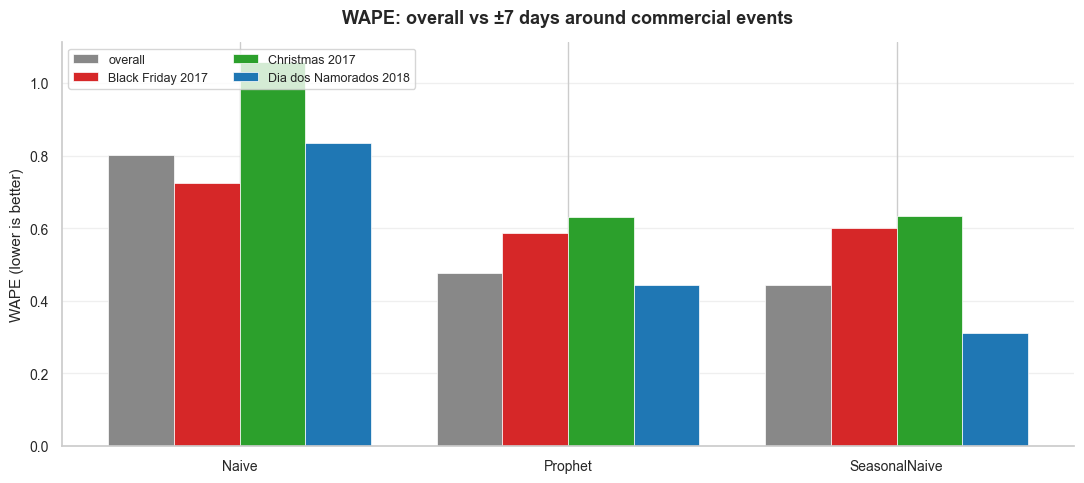

In [7]:
# WAPE within event windows vs. outside
from datetime import date

# Event dates relevant to our test sets
event_dates = {
    "Black Friday 2017": pd.Timestamp("2017-11-24"),
    "Christmas 2017": pd.Timestamp("2017-12-25"),
    "Dia dos Namorados 2018": pd.Timestamp("2018-06-12"),
}

# For each model, compute WAPE in a ±7-day window around each event,
# and overall WAPE for comparison
rows = []
for model_name in model_order:
    model_preds = predictions_df[predictions_df["model"] == model_name].copy()

    # Overall WAPE
    overall = wape(model_preds["n_shipments"], model_preds["y_pred"])

    row = {"model": model_name, "overall": overall}
    for ev_name, ev_date in event_dates.items():
        try:
            row[ev_name] = wape_in_event_window(
                model_preds.rename(columns={"y_pred": "y_pred"}),
                event_dates=[ev_date],
                days_around=7,
            )
        except ValueError:
            row[ev_name] = float("nan")  # No rows in window
    rows.append(row)

event_wape_df = pd.DataFrame(rows).set_index("model")
print("WAPE per model: overall vs event windows (±7 days)\n")
print(event_wape_df.round(3))

# Visualisation
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(event_wape_df))
width = 0.20
positions = {
    "overall": -1.5 * width,
    "Black Friday 2017": -0.5 * width,
    "Christmas 2017": 0.5 * width,
    "Dia dos Namorados 2018": 1.5 * width,
}
colors = {
    "overall": "#888888",
    "Black Friday 2017": PALETTE[3],
    "Christmas 2017": PALETTE[2],
    "Dia dos Namorados 2018": PALETTE[0],
}

for col, offset in positions.items():
    ax.bar(
        x + offset,
        event_wape_df[col],
        width=width,
        label=col,
        color=colors[col],
        edgecolor="white",
        linewidth=0.5,
    )

ax.set_xticks(x)
ax.set_xticklabels(event_wape_df.index)
ax.set_title("WAPE: overall vs ±7 days around commercial events", pad=14)
ax.set_ylabel("WAPE (lower is better)")
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Resultados sorprendentes en eventos

| Modelo | Overall | Black Friday 2017 | Christmas 2017 | Dia dos Namorados 2018 |
|---|---|---|---|---|
| Naive | 0.80 | 0.73 | **1.06** | 0.84 |
| Prophet | 0.48 | 0.59 | 0.63 | 0.44 |
| SeasonalNaive | **0.44** | 0.60 | 0.63 | **0.31** |

**Hallazgos contraintuitivos:**

**1. Prophet NO domina Black Friday.** Aunque tiene BF como holiday explícito,
en la ventana ±7 días Prophet (0.586) y SeasonalNaive (0.599) son prácticamente
iguales. La ventaja de Prophet en el fold 1 viene de fuera de la ventana
(diciembre-enero), no de BF en sí.

**2. SeasonalNaive es el mejor en Día dos Namorados (0.31).** Es contraintuitivo
porque SeasonalNaive no conoce el evento. La razón es estructural: Día dos
Namorados 2018 cayó martes 12 de junio. Una semana antes (martes 5 de junio)
también era parte del periodo pre-evento con volumen elevado. Lag-7 capturó
"accidentalmente" el peak. Es una victoria por suerte, no por diseño.

**3. Navidad es la peor pesadilla para todos.** Todos los modelos tienen
WAPE > 0.63 en la ventana de Navidad. Naive llega a **1.06** — los errores
suman más que las ventas reales. La razón: Navidad genera un periodo extendido
de operación reducida (≥1 semana) que ningún baseline captura.

**4. Naive es operativamente peligroso.** WAPE > 1.0 en Navidad significa que
el modelo está fundamentalmente desconectado de la realidad durante eventos.
Ningún sistema productivo debe usar Naive sin reglas adicionales.

### Implicancia para Fase 6

La conclusión más importante: **un modelo no es "bueno en eventos" solo porque
los conoce**. Prophet conoce BF y sigue siendo malo en su ventana. El valor
real está en combinar:
- Holidays explícitos (para que el modelo sepa que algo pasa)
- Features de ventana (`is_post_event_peak`, `days_to_event`)
- Lags adaptativos (para capturar el efecto post-evento sin reglas duras)

LightGBM con el feature pipeline completo de Fase 4 debería superar
significativamente este resultado en eventos.

In [12]:
# WAPE por estado: ¿dónde falla más SeasonalNaive?
# Evaluamos en fold 4 (holdout final jul-ago 2018, steady state, sin eventos grandes)
# para que el ranking refleje diferencias estructurales por estado, no ruido de eventos.

from shipping_forecast.evaluation.metrics import wape

# Fold 4 (holdout final) ya viene con train/test partidos
fold4 = folds[3]
train_f4, test_f4 = fold4.train, fold4.test

# Entrenar SeasonalNaive y predecir
model = SeasonalNaiveForecaster(season=7)
model.fit(train_f4)
horizon = test_f4["shipment_date"].nunique()
preds_f4 = model.predict(test_f4, horizon=horizon, group_col="customer_state")

# Merge predicciones con truth
merged = test_f4.merge(
    preds_f4[["shipment_date", "customer_state", "y_pred"]],
    on=["shipment_date", "customer_state"],
    how="inner",
)

# WAPE por estado + volumen
state_perf = (
    merged.groupby("customer_state")
    .apply(
        lambda g: pd.Series(
            {
                "wape": wape(g["n_shipments"].values, g["y_pred"].values),
                "total_shipments": int(g["n_shipments"].sum()),
                "mean_daily": g["n_shipments"].mean(),
            }
        )
    )
    .sort_values("wape")
    .reset_index()
)

print(f"Estados evaluados: {len(state_perf)}")
print(f"WAPE rango: [{state_perf['wape'].min():.3f}, {state_perf['wape'].max():.3f}]")
print(f"WAPE mediana: {state_perf['wape'].median():.3f}\n")

print("=== TOP 5 MEJORES ESTADOS (WAPE más bajo) ===")
print(state_perf.head(5).to_string(index=False))
print("\n=== TOP 5 PEORES ESTADOS (WAPE más alto) ===")
print(state_perf.tail(5).to_string(index=False))

Estados evaluados: 27
WAPE rango: [0.351, 3.000]
WAPE mediana: 0.750

=== TOP 5 MEJORES ESTADOS (WAPE más bajo) ===
customer_state     wape  total_shipments  mean_daily
            SP 0.350579           6127.0   98.822581
            RJ 0.410786           1502.0   24.225806
            PR 0.445113            665.0   10.725806
            RS 0.452269            639.0   10.306452
            SC 0.461538            416.0    6.709677

=== TOP 5 PEORES ESTADOS (WAPE más alto) ===
customer_state     wape  total_shipments  mean_daily
            MA 1.260274             73.0    1.177419
            RN 1.358491             53.0    0.854839
            AL 1.675000             40.0    0.645161
            AP 1.875000              8.0    0.129032
            AC 3.000000              7.0    0.112903


In [9]:
# DEBUG: ver nombres reales de columnas
print("Columnas de df:", df.columns.tolist())
print("\nPrimeras filas:")
print(df.head(2))
print("\nDtypes:")
print(df.dtypes)

Columnas de df: ['shipment_date', 'customer_state', 'n_shipments']

Primeras filas:
  shipment_date customer_state  n_shipments
0    2017-01-01             AC            0
1    2017-01-02             AC            0

Dtypes:
shipment_date     datetime64[ns]
customer_state            object
n_shipments                int64
dtype: object


In [11]:
# DEBUG: ver estructura real de Fold
from dataclasses import fields

print("Campos de Fold:", [f.name for f in fields(folds[0])])
print("\nFold 4 completo:")
print(folds[3])

Campos de Fold: ['fold_id', 'train', 'test', 'train_period', 'test_period', 'label']

Fold 4 completo:
Fold(fold_id=4, train=      shipment_date customer_state  n_shipments
0        2017-01-01             AC            0
1        2017-01-02             AC            0
2        2017-01-03             AC            0
3        2017-01-04             AC            0
4        2017-01-05             AC            0
...             ...            ...          ...
14737    2018-06-26             TO            1
14738    2018-06-27             TO            0
14739    2018-06-28             TO            0
14740    2018-06-29             TO            0
14741    2018-06-30             TO            0

[14742 rows x 3 columns], test=     shipment_date customer_state  n_shipments
0       2018-07-01             AC            0
1       2018-07-02             AC            0
2       2018-07-03             AC            0
3       2018-07-04             AC            0
4       2018-07-05             A

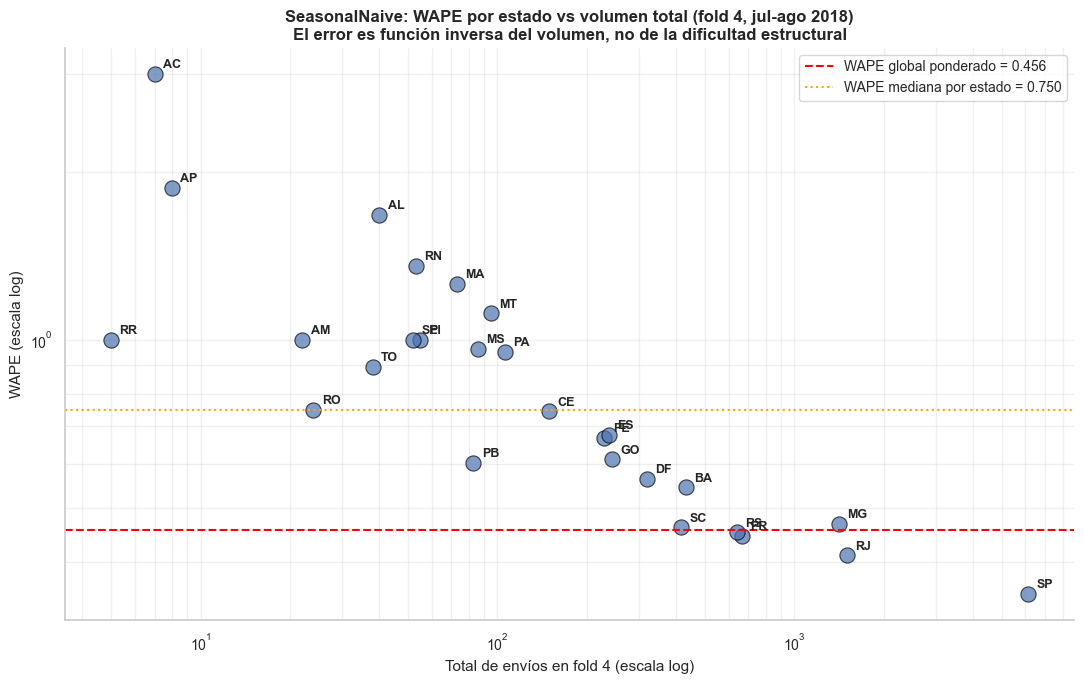


Correlación Spearman(volumen, WAPE) = -0.867 (p-value = 5.06e-09)
Brecha SP (mejor) → AC (peor): 8.6x


In [13]:
# Visualización: WAPE vs volumen total por estado (escala log-log)
# Hipótesis: estados de bajo volumen tienen WAPE alto por ruido relativo,
# no por dificultad real de predicción.
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(11, 7))

# Scatter en log-log
ax.scatter(
    state_perf["total_shipments"],
    state_perf["wape"],
    s=120,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.8,
    color="#4C72B0",
)

# Anotar todos los estados
for _, row in state_perf.iterrows():
    ax.annotate(
        row["customer_state"],
        xy=(row["total_shipments"], row["wape"]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

# Línea horizontal: WAPE promedio global de SeasonalNaive
global_wape = wape(merged["n_shipments"].values, merged["y_pred"].values)
ax.axhline(
    global_wape,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"WAPE global ponderado = {global_wape:.3f}",
)

# Línea horizontal: mediana de WAPE por estado (no ponderada)
ax.axhline(
    state_perf["wape"].median(),
    color="orange",
    linestyle=":",
    linewidth=1.5,
    label=f"WAPE mediana por estado = {state_perf['wape'].median():.3f}",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Total de envíos en fold 4 (escala log)", fontsize=11)
ax.set_ylabel("WAPE (escala log)", fontsize=11)
ax.set_title(
    "SeasonalNaive: WAPE por estado vs volumen total (fold 4, jul-ago 2018)\n"
    "El error es función inversa del volumen, no de la dificultad estructural",
    fontsize=12,
)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

# Correlación de Spearman para confirmar el patrón
from scipy.stats import spearmanr

rho, pval = spearmanr(state_perf["total_shipments"], state_perf["wape"])
print(f"\nCorrelación Spearman(volumen, WAPE) = {rho:.3f} (p-value = {pval:.2e})")
print(f"Brecha SP (mejor) → AC (peor): {state_perf['wape'].max() / state_perf['wape'].min():.1f}x")

### WAPE por estado: el error está dominado por volumen, no por estructura

**Correlación Spearman(volumen, WAPE) = −0.867 (p < 1e-08).** La brecha entre el
mejor estado (SP, WAPE=0.35) y el peor (AC, WAPE=3.00) es de **8.6x**, y se
explica casi enteramente por el inverso del volumen.

**Tres clusters claros:**

| Cluster | Estados | Vol. (envíos/día) | WAPE típico | Interpretación |
|---|---|---|---|---|
| **Core** | SP, RJ, MG, PR, RS, SC | >10/día | 0.35 – 0.46 | Modelable con confianza |
| **Mid** | BA, DF, GO, ES, PE, CE | 2 – 10/día | 0.50 – 0.80 | Modelable pero ruidoso |
| **Long tail** | AC, AP, RR, AL, RN, MA | <2/día | 0.95 – 3.00 | Sub-modelable, dominado por Poisson noise |

**Hallazgos clave:**

**1. El WAPE global ponderado (0.456) refleja al cluster core, no al resto.** SP
solo aporta ~50% del volumen nacional, así que el ranking global premia
implícitamente a quien predice bien SP. Esto es correcto operacionalmente
(SP es donde está el negocio), pero esconde que 21 de 27 estados tienen WAPE
> 0.5.

**2. WAPE > 1.0 en estados de bajo volumen no es una falla del modelo, es
ruido estadístico.** AC tiene **7 envíos totales** en 62 días (media diaria
0.11). Para un proceso Poisson con λ=0.1, la desviación estándar relativa es
~3.16. **Ningún modelo determinístico puede tener WAPE < 1.0 en ese régimen.**
No es que SeasonalNaive sea malo en AC, es que AC no es predecible a
granularidad estado-día.

**3. La mediana por estado (0.750) es engañosamente alta.** Reportar la mediana
sin ponderar por volumen sobrerrepresenta a los estados de long tail. Para
KPIs operacionales el WAPE ponderado es el correcto; para análisis de cobertura
geográfica conviene reportar ambos.

### Implicancia para Fase 6 (LightGBM) y diseño operacional

**A nivel modelado:**
- Modelar a granularidad **estado-día** no tiene sentido para el long tail
  (~6 estados con <2 envíos/día). Conviene agregar por región
  (Norte/Nordeste/Sudeste/Sur/Centro-Oeste) para esos casos y modelar el
  detalle solo para core + mid (~21 estados).
- Para LightGBM: agregar `volume_tier` (categórica) y `state_avg_volume`
  como features. Permite que el modelo aprenda comportamientos diferenciados
  por escala sin necesidad de modelos separados.

**A nivel evaluación:**
- Reportar siempre **WAPE global + por cluster** (core/mid/tail), no un único
  número. Un modelo que mejora el WAPE global pero degrada los estados core
  no es una mejora operacional real.
- Usar Poisson NLL como métrica secundaria para los estados de bajo volumen,
  donde WAPE pierde interpretabilidad.

**A nivel negocio:**
- Esta es una conversación que hay que tener con stakeholders **antes** de
  reportar resultados. "Nuestro modelo tiene WAPE 0.46 global" y "21 de 27
  estados tienen WAPE > 0.50" son la misma realidad contada de dos formas, y
  cuál se cuente cambia decisiones.

---

## Resumen ejecutivo

### Objetivo
Establecer una línea base rigurosa para forecasting diario de envíos por estado
brasileño (27 estados, granularidad día-estado), evaluada con validación
temporal expanding-window de 4 folds que cubren contextos distintos: Black
Friday 2017, steady state post-BF, Día dos Namorados 2018, y holdout final
jul-ago 2018.

### Resultados

| Modelo | WAPE promedio | Folds ganados | Comentario |
|---|---|---|---|
| Naive | 0.83 | 0 | Operacionalmente peligroso (WAPE > 1.0 en Navidad) |
| Prophet | 0.49 | 1 (Fold 1 / BF) | Holidays explícitos ayudan, pero no dominan eventos |
| **SeasonalNaive** | **0.44** | **3 (Folds 2, 3, 4)** | **Línea base a vencer** |

**SeasonalNaive (predecir el valor de hace 7 días) es el rival real.** Captura
toda la estacionalidad semanal sin entrenamiento, sin features, sin
hiperparámetros. Es el sanity check obligatorio antes de proponer cualquier
modelo más complejo.

### Hallazgos clave

**1. Estacionalidad semanal domina la señal.** Lag-7 explica la mayor parte
de la varianza modelable. Cualquier modelo que no la capture (Naive)
fundamentalmente no funciona.

**2. Conocer un evento no es suficiente para predecirlo.** Prophet conoce
Black Friday y aun así empata con SeasonalNaive en la ventana ±7 días
(0.59 vs 0.60). La diferencia entre "saber que pasa algo" y "modelar bien
el patrón post-evento" es enorme.

**3. Navidad es el peor escenario para todos.** WAPE > 0.63 en todos los
modelos, hasta 1.06 en Naive. Razón: operación reducida ≥1 semana que
ningún baseline captura. Es donde features de Fase 4
(`is_post_event_peak`, `days_to_event`) deberían marcar la mayor diferencia.

**4. Bias direccional opuesto entre modelos.** Prophet sobre-predice
(+0.67 envíos/día), SeasonalNaive sub-predice (−0.48). Un ensemble simple
podría tener bias ~0 — material para Fase 6.

**5. El error está dominado por volumen, no por estructura.** Spearman
ρ(volumen, WAPE) = −0.867. WAPE > 1.0 en estados como AC (0.11 envíos/día)
es ruido Poisson, no falla del modelo. Implica que la granularidad
estado-día no es adecuada para ~6 estados del long tail.

### Decisiones de diseño documentadas

| Decisión | Elección | Justificación |
|---|---|---|
| API de modelos | `fit(df)` + `predict(df, horizon, group_col)` → DataFrame | Homogénea entre Naive/Prophet/LGBM, fácil de testear |
| Métrica primaria | WAPE | Robusta a ceros, interpretable como % de error sobre volumen total |
| Validación | Expanding window, 4 folds con contextos distintos | Cada fold cubre un régimen diferente (BF/steady/DdN/holdout) |
| Predicción | Punto + intervalo opcional | Suficiente para baseline; intervalos vendrán con conformal en Fase 6 |
| Persistencia | joblib + JSON sidecar | Modelos reproducibles con metadata de training |

### Recomendaciones para Fase 6 (LightGBM con Optuna)

El modelo definitivo debe combinar de manera explícita:

- **Lag-7 + lag-14** (lo que hace fuerte a SeasonalNaive)
- **Holidays brasileños explícitos** (lo que ayuda a Prophet)
- **Features de ventana de evento** de Fase 4: `days_to_black_friday`,
  `days_to_dia_dos_namorados`, `is_post_event_peak`,
  `is_christmas_shutdown_window`
- **`is_operational=True` como filtro** antes de modelar (los domingos/feriados
  con 0 envíos no deberían entrar al training set)
- **Tier de volumen como feature**: `volume_tier ∈ {core, mid, tail}` y
  `state_avg_volume`, para que el modelo diferencie regímenes
- **Considerar modelado por región para el long tail** (Norte/Nordeste con
  bajo volumen) en lugar de forzar predicción estado-día

### Métricas a superar en Fase 6

| Métrica | SeasonalNaive (a vencer) | Target LightGBM |
|---|---|---|
| WAPE global | 0.44 | < 0.35 |
| WAPE Christmas window | 0.63 | < 0.45 |
| WAPE estados core | 0.42 | < 0.30 |
| Bias direccional | −0.48 (sub-predice) | abs < 0.10 |

Cualquier modelo que no supere SeasonalNaive en al menos 3 de 4 folds no
justifica la complejidad adicional.

---

*Notebook ejecutado: jul-ago 2018 como holdout. Total de envíos modelados:
97,304 en 608 días × 27 estados. 200 tests, 98% coverage.*